IMPORTS

In [ ]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load & preprocess data

In [ ]:

temperature_column = 1

df = pd.read_csv("jena_climate_2009_2016.csv")
data = df.drop(columns=["Date Time"])
data = data.groupby(data.index // 6).mean()

split_index = int(0.8 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

scaler = StandardScaler()
scaler.fit(train_data)          # fit on train (same as both notebooks)
val_data = scaler.transform(val_data)   # this array is identical in both notebooks

val_tensor = torch.from_numpy(val_data).float()

Model definitions

In [ ]:
# --- Transformer ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class WeatherTransformer(nn.Module):
    def __init__(self, input_size=14, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, output_size=24):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.2, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.fc(x)

In [ ]:
# --- LSTM ---
class LSTMcell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.forget_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.input_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.candidate_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.output_gate = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat((x, h_prev), dim=1)
        f = torch.sigmoid(self.forget_gate(combined))
        i = torch.sigmoid(self.input_gate(combined))
        g = torch.tanh(self.candidate_gate(combined))
        o = torch.sigmoid(self.output_gate(combined))
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_length):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell1 = LSTMcell(input_size, hidden_size)
        self.cell2 = LSTMcell(hidden_size, hidden_size)
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(hidden_size, output_length)

    def forward(self, x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]
        dev = x.device
        h1 = torch.zeros(batch_size, self.hidden_size, device=dev)
        c1 = torch.zeros(batch_size, self.hidden_size, device=dev)
        h2 = torch.zeros(batch_size, self.hidden_size, device=dev)
        c2 = torch.zeros(batch_size, self.hidden_size, device=dev)
        for t in range(seq_len):
            x_t = x[:, t, :]
            h1, c1 = self.cell1(x_t, h1, c1)
            h1 = self.dropout(h1)
            h2, c2 = self.cell2(h1, h2, c2)
        return self.fc(h2)

Load trained weights


In [ ]:

transformer = WeatherTransformer(
    input_size=14, d_model=64, nhead=4, num_layers=2,
    dim_feedforward=256, output_size=24
).to(device)
transformer.load_state_dict(torch.load("best_transformer (1).pth", map_location=device))
transformer.eval()

lstm = LSTM(input_size=14, hidden_size=64, output_length=12).to(device)
lstm.load_state_dict(torch.load("best_lstm.pth", map_location=device))
lstm.eval()

TRANSFORMER_INPUT_LEN = 720
LSTM_INPUT_LEN = 72
TRANSFORMER_OUTPUT_LEN = 24
LSTM_OUTPUT_LEN = 12

PLOTS

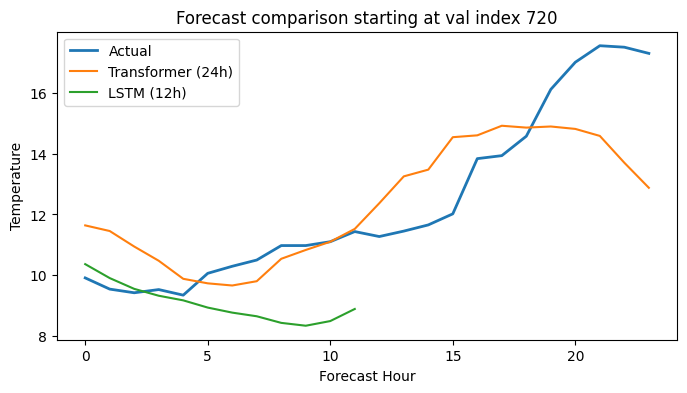

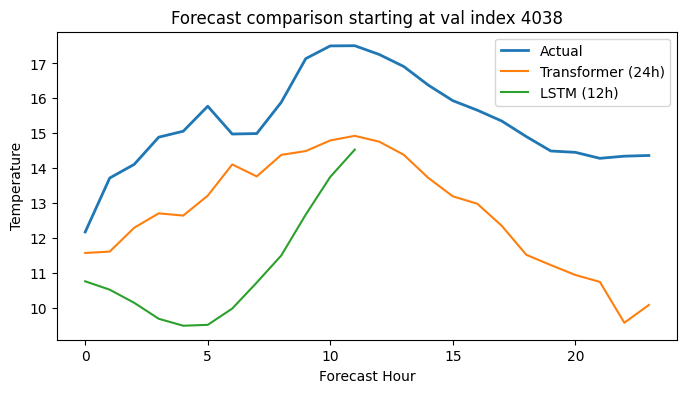

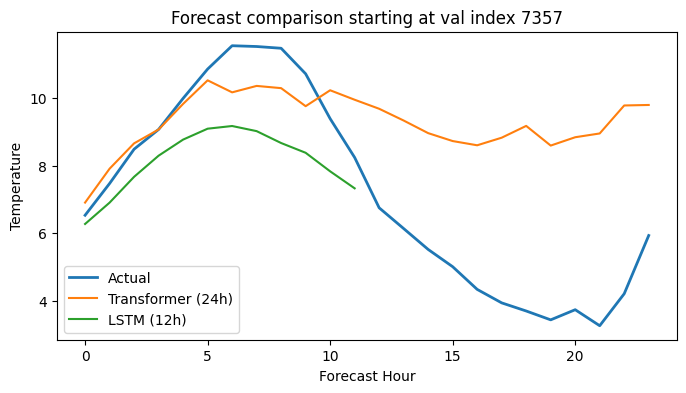

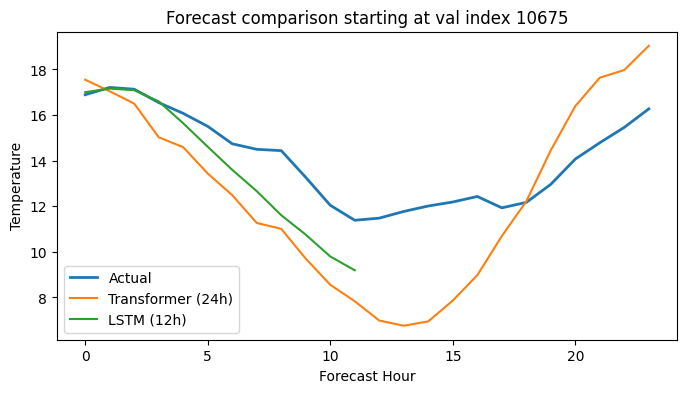

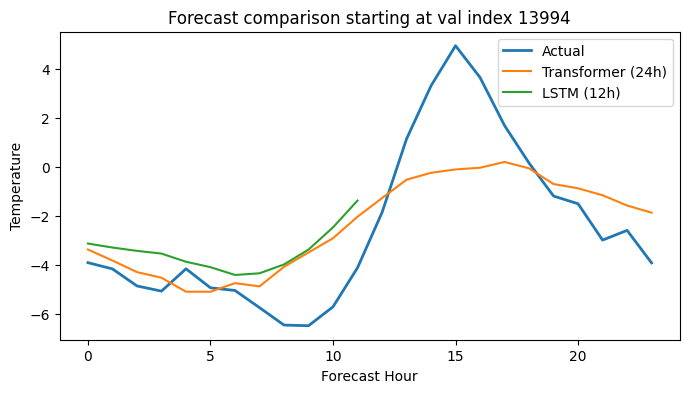

In [3]:

def forecast_at(t):
    """Run both models for a forecast window starting at index t of val_data."""
    x_transformer = val_tensor[t - TRANSFORMER_INPUT_LEN : t].unsqueeze(0).to(device)
    x_lstm = val_tensor[t - LSTM_INPUT_LEN : t].unsqueeze(0).to(device)

    with torch.no_grad():
        pred_transformer = transformer(x_transformer).cpu().numpy().flatten()
        pred_lstm = lstm(x_lstm).cpu().numpy().flatten()

    actual = val_tensor[t : t + TRANSFORMER_OUTPUT_LEN, temperature_column].numpy()

    # inverse-scale (only the temperature column)
    mean_t = scaler.mean_[temperature_column]
    scale_t = scaler.scale_[temperature_column]

    actual = actual * scale_t + mean_t
    pred_transformer = pred_transformer * scale_t + mean_t
    pred_lstm = pred_lstm * scale_t + mean_t

    return actual, pred_transformer, pred_lstm

earliest_valid_t = TRANSFORMER_INPUT_LEN  # 720, the binding constraint
latest_valid_t = len(val_data) - TRANSFORMER_OUTPUT_LEN

# 5 example windows, spaced out across the validation set
start_points = np.linspace(earliest_valid_t, latest_valid_t - 1, 5, dtype=int)

for i, t in enumerate(start_points):
    actual, pred_transformer, pred_lstm = forecast_at(t)

    plt.figure(figsize=(8, 4))
    plt.plot(range(TRANSFORMER_OUTPUT_LEN), actual, label="Actual", linewidth=2)
    plt.plot(range(TRANSFORMER_OUTPUT_LEN), pred_transformer, label="Transformer (24h)")
    plt.plot(range(LSTM_OUTPUT_LEN), pred_lstm, label="LSTM (12h)")

    plt.title(f"Forecast comparison starting at val index {t}")
    plt.xlabel("Forecast Hour")
    plt.ylabel("Temperature")
    plt.legend()
    plt.savefig(f"comparison_forecast_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.show()